In [3]:
# Mount & installs (run once)
from google.colab import drive
drive.mount('/content/drive')

!pip install -q torch torchvision torchaudio scikit-image matplotlib tqdm pillow requests

import os, torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")
BASE="/content/drive/MyDrive/image_compression_project"
os.makedirs(BASE, exist_ok=True)


Mounted at /content/drive
Device: cuda


In [4]:
transform = transforms.Compose([transforms.Resize((128,128)), transforms.ToTensor()])
train_ds = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
print("Train size:", len(train_ds))

100%|██████████| 170M/170M [00:03<00:00, 44.0MB/s]


Train size: 50000


In [5]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),
            nn.Conv2d(64,128,4,2,1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*16*16, latent_dim)
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 128*16*16),
            nn.Unflatten(1,(128,16,16)),
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(32,3,4,2,1), nn.Sigmoid()
        )
    def forward(self,x):
        z = self.enc(x)
        return self.dec(z)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(latent_dim=512).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


Epoch 1/8: 100%|██████████| 782/782 [00:48<00:00, 16.20it/s]


Epoch 1 avg loss 0.009707


Epoch 2/8: 100%|██████████| 782/782 [00:42<00:00, 18.37it/s]


Epoch 2 avg loss 0.002460


Epoch 3/8: 100%|██████████| 782/782 [00:43<00:00, 18.11it/s]


...

Epoch 6 avg loss 0.000851


Epoch 7/8: 100%|██████████| 782/782 [00:42<00:00, 18.27it/s]


Epoch 7 avg loss 0.000782


Epoch 8/8: 100%|██████████| 782/782 [00:43<00:00, 18.18it/s]


Epoch 8 avg loss 0.000697
Saved AE -> /content/drive/MyDrive/image_compression_project/models/ae_epoch8.pth


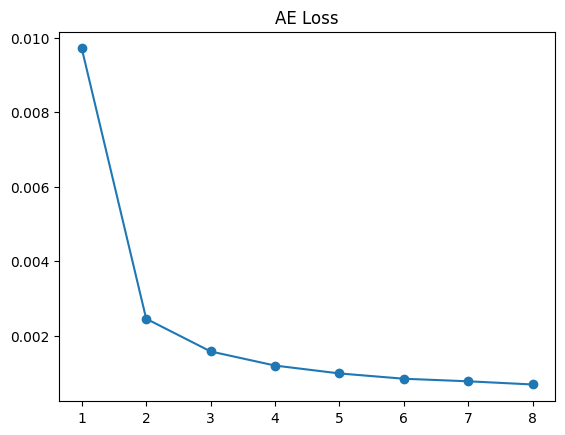

In [6]:
epochs = 8
train_losses=[]
for epoch in range(epochs):
    model.train()
    total=0
    for imgs,_ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        imgs = imgs.to(device)
        recon = model(imgs)
        loss = loss_fn(recon, imgs)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item()
    avg = total/len(train_loader)
    train_losses.append(avg)
    print(f"Epoch {epoch+1} avg loss {avg:.6f}")
# save model
torch.save(model.state_dict(), os.path.join(BASE,"models/ae_epoch8.pth"))
print("Saved AE ->", os.path.join(BASE,"models/ae_epoch8.pth"))
# save loss curve
import matplotlib.pyplot as plt
plt.plot(range(1,len(train_losses)+1), train_losses, marker='o'); plt.title("AE Loss"); plt.show()


In [7]:
# prepare test dataset (STL-10 test)
test_ds = datasets.STL10(root='data', split='test', download=True, transform=transform)
from torch.utils.data import DataLoader
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

import os
os.makedirs(os.path.join(BASE,"results/grids"), exist_ok=True)

from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

model.eval()
psnrs=[]; ssims=[]
import torchvision.utils as vutils
for i,(img,_) in enumerate(test_loader):
    if i>=24: break
    img = img.to(device)
    with torch.no_grad():
        rec = model(img)
    orig_np = img.cpu().squeeze(0).permute(1,2,0).numpy()
    rec_np  = rec.cpu().squeeze(0).permute(1,2,0).numpy()
    psnrs.append(psnr(orig_np, rec_np, data_range=1.0))
    ssims.append(ssim(orig_np, rec_np, channel_axis=-1, data_range=1.0, win_size=7))
    vutils.save_image(torch.cat([img.cpu(), rec.cpu()], dim=3), os.path.join(BASE,f"results/grids/ae_grid_{i+1:02d}.png"))
print("AE Avg PSNR:", np.mean(psnrs),"AE Avg SSIM:", np.mean(ssims))
# copy final sample grid
!cp {BASE}/results/grids/ae_grid_01.png {BASE}/results/grids/ae_sample01.png


100%|██████████| 2.64G/2.64G [00:40<00:00, 64.6MB/s]


AE Avg PSNR: 23.563057850005617 AE Avg SSIM: 0.6246346


In [8]:
torch.save(model.state_dict(), "/content/drive/MyDrive/image_compression_project/models/ae_epoch8.pth")

In [9]:
!ls /content/drive/MyDrive/image_compression_project/models


ae_epoch8.pth
